# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

# Loading data

In [2]:
df = pd.read_csv("../data/rfm_modeling_snapshot.csv")

print(df.shape)
df.head()

(2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


# Preparing Features

In [3]:
X = df.drop(columns=["customer_id", "snapshot_date", "churn_next_60d", "split"])
y = df["churn_next_60d"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", len(numerical_cols))

Categorical: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']
Numerical: 19


In [4]:
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "validation"]
test_df = df[df["split"] == "test"]

X_train = train_df.drop(columns=["customer_id", "snapshot_date", "churn_next_60d", "split"])
y_train = train_df["churn_next_60d"]

X_val = val_df.drop(columns=["customer_id", "snapshot_date", "churn_next_60d", "split"])
y_val = val_df["churn_next_60d"]

X_test = test_df.drop(columns=["customer_id", "snapshot_date", "churn_next_60d", "split"])
y_test = test_df["churn_next_60d"]

print(X_train.shape, X_val.shape, X_test.shape)

(1728, 25) (336, 25) (336, 25)


# Preprocessing Pipeline

In [5]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Logistic Regression (Baseline Model)

In [6]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

val_probs_log = log_model.predict_proba(X_val)[:, 1]
val_preds_log = (val_probs_log >= 0.5).astype(int)

print("Baseline Model - Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_val, val_probs_log))
print("F1 Score:", f1_score(y_val, val_preds_log))
print(classification_report(y_val, val_preds_log))

Baseline Model - Logistic Regression
ROC-AUC: 0.8826980527660799
F1 Score: 0.7832167832167832
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       189
           1       0.81      0.76      0.78       147

    accuracy                           0.82       336
   macro avg       0.81      0.81      0.81       336
weighted avg       0.82      0.82      0.81       336



# Random Forest (Strong Model)

In [7]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

val_probs_rf = rf_model.predict_proba(X_val)[:, 1]
val_preds_rf = (val_probs_rf >= 0.5).astype(int)

print("Random Forest Results")
print("ROC-AUC:", roc_auc_score(y_val, val_probs_rf))
print("F1 Score:", f1_score(y_val, val_preds_rf))
print(classification_report(y_val, val_preds_rf))

Random Forest Results
ROC-AUC: 0.8772630745419862
F1 Score: 0.7642857142857142
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       189
           1       0.80      0.73      0.76       147

    accuracy                           0.80       336
   macro avg       0.80      0.80      0.80       336
weighted avg       0.80      0.80      0.80       336



# Threshold Selection

In [8]:
threshold = 0.40

test_probs = rf_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= threshold).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "f1_score": f1_score(y_test, test_preds),
    "roc_auc": roc_auc_score(y_test, test_probs),
    "threshold": threshold
}

print(metrics)

{'accuracy': 0.8244047619047619, 'precision': 0.8044692737430168, 'recall': 0.8571428571428571, 'f1_score': 0.829971181556196, 'roc_auc': 0.8846017573696144, 'threshold': 0.4}


# Confusion Matrix

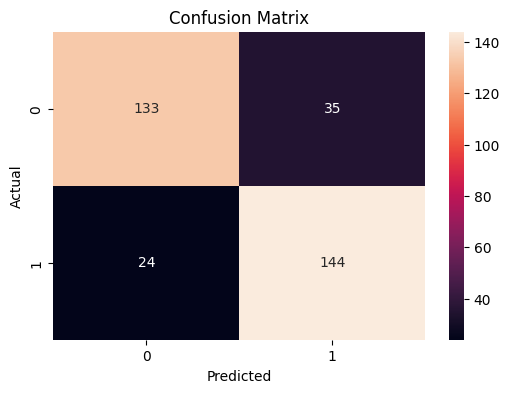

In [9]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Feature Importance and Analysis

In [10]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 10 Features")
display(importance_df.head(10))

error_df = test_df.copy()
error_df["predicted"] = test_preds
error_df["probability"] = test_probs

errors = error_df[
    error_df["churn_next_60d"] != error_df["predicted"]
][["customer_id", "churn_next_60d", "predicted", "probability"]]

display(errors.head(10))

Top 10 Features


,feature,importance
0,num__recency_days,0.267966
18,num__last_visit_days_ago,0.157630
2,num__monetary_180d,0.085733
1,num__frequency_180d,0.051495
6,num__category_diversity_180d,0.046045
12,num__product_views_30d,0.045936
4,num__avg_discount_pct_180d,0.042793
10,num__days_since_signup,0.042459
11,num__sessions_30d,0.036503
5,num__avg_rating_180d,0.021524


,customer_id,churn_next_60d,predicted,probability
43,CUST00044,0,1,0.471271
108,CUST00109,0,1,0.565647
183,CUST00184,1,0,0.085805
246,CUST00247,1,0,0.343565
334,CUST00335,0,1,0.654394
413,CUST00414,1,0,0.379722
436,CUST00437,0,1,0.880331
437,CUST00438,1,0,0.317004
490,CUST00491,0,1,0.582722
530,CUST00531,1,0,0.365088


# Saving model and Metrics

In [11]:
joblib.dump(rf_model, "../model.pkl")

with open("../metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Model saved as model.pkl")
print("Metrics saved as metrics.json")

Model saved as model.pkl
Metrics saved as metrics.json
